In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
uy_metrics = Path("./peak_metrics/uruguay")
us_results = Path("./peak_metrics/united_states")

# UY

In [3]:
df_results = pd.read_csv(uy_metrics / "peak_metrics.csv")

In [4]:
PRECIP_COLS = {
    "CARAVAN":   "prcp_mm_day",
    "CHIRPS": "prcp_chirps_mm_day",
    "MSWEP":  "prcp_mswep_mm_day",

}

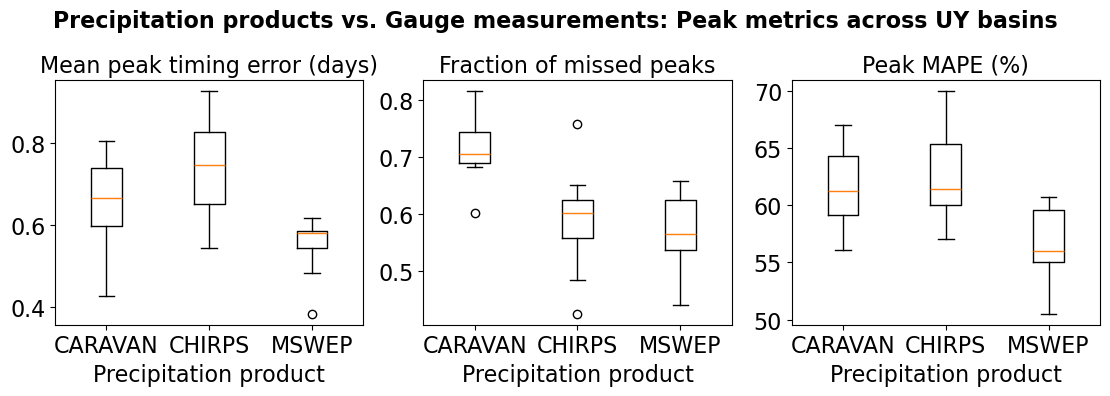

In [5]:
metrics = {
    "peak_timing":  "Mean peak timing error (days)",
    "missed_peaks": "Fraction of missed peaks",
    "mape_peak":    "Peak MAPE (%)",
}

# fig, axes = plt.subplots(1, len(metrics), figsize=(14, 5))
fig, axes = plt.subplots(1, len(metrics), figsize=(11.2, 4))

for ax, (metric, label) in zip(axes, metrics.items()):
    data = [
        df_results.loc[df_results["product"] == p, metric].dropna().values
        for p in PRECIP_COLS
    ]
    ax.boxplot(data, tick_labels=list(PRECIP_COLS.keys())) #, patch_artist=True)
    ax.set_title(label, fontsize=16)
    ax.set_xlabel("Precipitation product", fontsize=16)

    ax.tick_params(axis='x', labelsize=16)  
    ax.tick_params(axis='y', labelsize=16)  

plt.suptitle("Precipitation products vs. Gauge measurements: Peak metrics across UY basins", fontsize=16, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

# US

In [6]:
df_results_us = pd.read_csv(us_results / "peak_metrics.csv")

In [7]:
PRECIP_COLS_US = {
    "CARAVAN":   "total_precipitation_sum",
    "CHIRPS":   "chirps_precipitation",
    "MSWEP":    "mswep_precipitation",
}

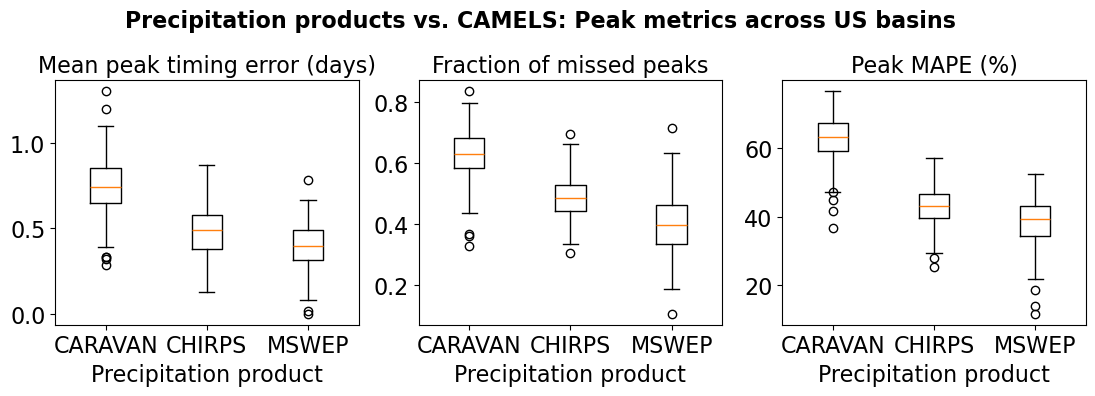

In [10]:
# ── Plot ──────────────────────────────────────────────────────────────────────
metrics = {
    "peak_timing":  "Mean peak timing error (days)",
    "missed_peaks": "Fraction of missed peaks",
    "mape_peak":    "Peak MAPE (%)",
}

# fig, axes = plt.subplots(1, len(metrics), figsize=(14, 5))
fig, axes = plt.subplots(1, len(metrics), figsize=(11.2, 4))

for ax, (metric, label) in zip(axes, metrics.items()):
    data = [
        df_results_us.loc[df_results_us["product"] == p, metric].dropna().values
        for p in PRECIP_COLS_US
    ]
    ax.boxplot(data, tick_labels=list(PRECIP_COLS_US.keys())) #, patch_artist=True)
    ax.set_title(label, fontsize=16)
    ax.set_xlabel("Precipitation product", fontsize=16)

    ax.tick_params(axis='x', labelsize=16)  
    ax.tick_params(axis='y', labelsize=16)  

plt.suptitle("Precipitation products vs. CAMELS: Peak metrics across US basins", fontsize=16, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()